# Avance 2 — Feature Engineering y Preparación de Datos
## Monitoreo de estrés hídrico en parcelas aguacateras con Sentinel‑2

Este notebook continúa a partir de `level2_patch_dataset_with_labels.csv`, que relaciona cada **patch GeoTIFF** con su parcela, fecha e índices espectrales.

La fase corresponde a **Data Preparation / Feature Engineering** dentro de CRISP‑ML. El objetivo es convertir datos crudos del mundo real —imágenes satelitales, índices espectrales, fechas y categorías en variables útiles para aprendizaje automático.

### Objetivos
- **2.3** Crear nuevas características para mejorar el desempeño del modelo.
- **2.4** Mitigar riesgos asociados a características identificadas y acelerar la convergencia de ciertos algoritmos.

### Enfoque
Para imágenes satelitales hay dos caminos complementarios:

1. **Features tabulares:** extraer estadísticas por banda de cada GeoTIFF (`mean`, `std`, percentiles, etc.).
2. **Matrices para CNN:** conservar cada patch como tensor multibanda `(channels, height, width)`.

No se recomienda convertir cada píxel RGB en una columna tabular, porque aumentaría demasiado la dimensionalidad y el riesgo de sobreajuste. Para modelos clásicos usaremos estadísticas compactas; para CNN conservaremos la matriz multibanda.


In [4]:
# ============================================================
# 0. Imports and configuration
# ============================================================

from pathlib import Path
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import rasterio
from rasterio.enums import Resampling

from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

RANDOM_STATE = 42


## 1. Rutas de trabajo

Ajusta las rutas de acuerdo con tu computadora. El archivo principal debe ser:

`level2_patch_dataset_with_labels.csv`

y debe contener columnas como:

- `name`
- `year`
- `month`
- `year_month`
- `patch_path`
- `NDVI`
- `NDMI`


In [5]:
# ============================================================
# 1. Paths
# ============================================================

BASE_DIR = Path(r"C:\Users\omarh\Desktop\Maestria\avocado_project")

DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"

PATCH_DATASET_CSV = PROCESSED_DIR / "level2_patch_dataset_with_labels.csv"
OUTPUT_DIR = PROCESSED_DIR / "feature_engineering"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Patch dataset:", PATCH_DATASET_CSV)
print("Output folder:", OUTPUT_DIR)


Patch dataset: C:\Users\omarh\Desktop\Maestria\avocado_project\data\processed\level2_patch_dataset_with_labels.csv
Output folder: C:\Users\omarh\Desktop\Maestria\avocado_project\data\processed\feature_engineering


In [6]:
# ============================================================
# 2. Load Level 2 dataset
# ============================================================

df = pd.read_csv(PATCH_DATASET_CSV)

print("Shape:", df.shape)
display(df.head())
display(df.info())

if "year_month" not in df.columns:
    df["year_month"] = df["year_x"].astype(str) + "-" + df["month_x"].astype(str).str.zfill(2)

df["year_x"] = df["year_x"].astype(int)
df["month_x"] = df["month_x"].astype(int)

df["patch_path"] = df["patch_path"].astype(str)
df["patch_exists"] = df["patch_path"].apply(lambda p: Path(p).exists())

print("Existing patch files:", df["patch_exists"].sum(), "of", len(df))
display(df["patch_exists"].value_counts())


Shape: (4100, 13)


,name,year_x,month_x,year_month,patch_path,lat,lon,year_y,month_y,date,image_count,NDVI,NDMI
0,H1,2023,1,2023-01,C:\Users\omarh\Desktop\Maestria\avocado_projec...,19.663164,-103.48747,2023.0,1.0,2023-01,4.0,0.319492,-0.063829
1,H1,2023,2,2023-02,C:\Users\omarh\Desktop\Maestria\avocado_projec...,19.663164,-103.48747,2023.0,2.0,2023-02,6.0,0.240143,-0.107686
2,H1,2023,3,2023-03,C:\Users\omarh\Desktop\Maestria\avocado_projec...,19.663164,-103.48747,2023.0,3.0,2023-03,6.0,0.218621,-0.139270
3,H1,2023,4,2023-04,C:\Users\omarh\Desktop\Maestria\avocado_projec...,19.663164,-103.48747,2023.0,4.0,2023-04,6.0,0.194678,-0.141275
4,H1,2023,5,2023-05,C:\Users\omarh\Desktop\Maestria\avocado_projec...,19.663164,-103.48747,2023.0,5.0,2023-05,6.0,0.197294,-0.153916


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4100 entries, 0 to 4099
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         4100 non-null   object 
 1   year_x       4100 non-null   int64  
 2   month_x      4100 non-null   int64  
 3   year_month   4100 non-null   object 
 4   patch_path   4100 non-null   object 
 5   lat          4000 non-null   float64
 6   lon          4000 non-null   float64
 7   year_y       4000 non-null   float64
 8   month_y      4000 non-null   float64
 9   date         4000 non-null   object 
 10  image_count  4000 non-null   float64
 11  NDVI         4000 non-null   float64
 12  NDMI         4000 non-null   float64
dtypes: float64(7), int64(2), object(4)
memory usage: 416.5+ KB


None

Existing patch files: 4100 of 4100


patch_exists
True    4100
Name: count, dtype: int64

## 2. Variable objetivo preliminar

Como todavía no existen etiquetas agronómicas de campo, se define una etiqueta relativa basada en NDMI:

- `severe_possible_stress`: NDMI ≤ percentil 10.
- `moderate_possible_stress`: percentil 10 < NDMI ≤ percentil 25.
- `no_relative_stress`: NDMI > percentil 25.

Esta clase no confirma estrés real; funciona como proxy preliminar para probar pipelines de clasificación.


,stress_class,count,percentage
0,no_relative_stress,3000,73.170732
1,moderate_possible_stress,600,14.634146
2,severe_possible_stress,400,9.756098
3,NaN,100,2.439024


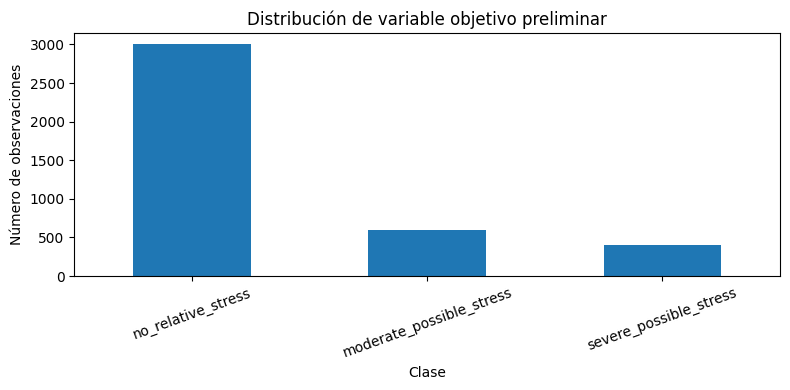

In [7]:
# ============================================================
# 3. Preliminary target variable
# ============================================================

df_model = df.copy()

df_model["NDVI"] = pd.to_numeric(df_model["NDVI"], errors="coerce")
df_model["NDMI"] = pd.to_numeric(df_model["NDMI"], errors="coerce")

q10 = df_model["NDMI"].quantile(0.10)
q25 = df_model["NDMI"].quantile(0.25)

def classify_relative_stress(ndmi):
    if pd.isna(ndmi):
        return np.nan
    if ndmi <= q10:
        return "severe_possible_stress"
    elif ndmi <= q25:
        return "moderate_possible_stress"
    else:
        return "no_relative_stress"

df_model["stress_class"] = df_model["NDMI"].apply(classify_relative_stress)

target_summary = df_model["stress_class"].value_counts(dropna=False).rename_axis("stress_class").reset_index(name="count")
target_summary["percentage"] = target_summary["count"] / len(df_model) * 100
display(target_summary)

plt.figure(figsize=(8, 4))
df_model["stress_class"].value_counts().plot(kind="bar")
plt.title("Distribución de variable objetivo preliminar")
plt.xlabel("Clase")
plt.ylabel("Número de observaciones")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 3. Generación de nuevas características

### 3.1 Variables temporales

El mes es una variable cíclica; enero y diciembre están cercanos aunque numéricamente sean 1 y 12. Por ello se generan:

- `month_sin`
- `month_cos`

También se genera `dry_season` para representar de manera simple la temporada seca.


In [10]:
# ============================================================
# 4.1 Temporal feature engineering
# ============================================================

fe = df_model.copy()

fe["month_x_sin"] = np.sin(2 * np.pi * fe["month_x"] / 12)
fe["month_x_cos"] = np.cos(2 * np.pi * fe["month_x"] / 12)

# Nov-May as dry season approximation
fe["dry_season"] = fe["month_x"].isin([11, 12, 1, 2, 3, 4, 5]).astype(int)

def assign_season(month):
    if month in [12, 1, 2]:
        return "winter_dry"
    elif month in [3, 4, 5]:
        return "spring_dry"
    elif month in [6, 7, 8, 9]:
        return "rainy"
    else:
        return "late_rainy_transition"

fe["season"] = fe["month_x"].apply(assign_season)

display(fe[["name", "year_month", "month_x", "month_x_sin", "month_x_cos", "dry_season", "season"]].head())


,name,year_month,month_x,month_x_sin,month_x_cos,dry_season,season
0,H1,2023-01,1,0.500000,8.660254e-01,1,winter_dry
1,H1,2023-02,2,0.866025,5.000000e-01,1,winter_dry
2,H1,2023-03,3,1.000000,6.123234e-17,1,spring_dry
3,H1,2023-04,4,0.866025,-5.000000e-01,1,spring_dry
4,H1,2023-05,5,0.500000,-8.660254e-01,1,spring_dry


### 3.2 Variables espectrales derivadas y binning

Se generan variables que combinan NDVI y NDMI:

- `NDVI_minus_NDMI`
- `NDVI_NDMI_product`
- `NDMI_to_NDVI_ratio`

Además, NDVI y NDMI se discretizan por cuantiles para generar clases interpretables de vigor y humedad.


In [11]:
# ============================================================
# 4.2 Spectral derived features and binning
# ============================================================

EPS = 1e-6

fe["NDVI_minus_NDMI"] = fe["NDVI"] - fe["NDMI"]
fe["NDVI_NDMI_product"] = fe["NDVI"] * fe["NDMI"]
fe["NDMI_to_NDVI_ratio"] = fe["NDMI"] / (fe["NDVI"].abs() + EPS)

fe["NDVI_bin"] = pd.qcut(fe["NDVI"], q=4, labels=["very_low", "low", "medium", "high"], duplicates="drop")
fe["NDMI_bin"] = pd.qcut(fe["NDMI"], q=4, labels=["very_low", "low", "medium", "high"], duplicates="drop")

display(fe[["NDVI", "NDMI", "NDVI_minus_NDMI", "NDVI_NDMI_product", "NDMI_to_NDVI_ratio", "NDVI_bin", "NDMI_bin"]].head())


,NDVI,NDMI,NDVI_minus_NDMI,NDVI_NDMI_product,NDMI_to_NDVI_ratio,NDVI_bin,NDMI_bin
0,0.319492,-0.063829,0.383321,-0.020393,-0.199781,very_low,very_low
1,0.240143,-0.107686,0.347829,-0.025860,-0.448422,very_low,very_low
2,0.218621,-0.139270,0.357890,-0.030447,-0.637035,very_low,very_low
3,0.194678,-0.141275,0.335953,-0.027503,-0.725683,very_low,very_low
4,0.197294,-0.153916,0.351211,-0.030367,-0.780133,very_low,very_low


### 3.3 Variables temporales por parcela

Para capturar dinámica temporal se generan:

- rezagos (`lag1`)
- cambios mensuales (`delta1`)
- medias móviles de 3 meses
- desviaciones móviles de 3 meses
- anomalías respecto al promedio histórico de cada parcela


In [13]:
# ============================================================
# 4.3 Lag, delta, rolling and anomaly features
# ============================================================

fe = fe.sort_values(["name", "year_x", "month_x"]).reset_index(drop=True)

for col in ["NDVI", "NDMI"]:
    fe[f"{col}_lag1"] = fe.groupby("name")[col].shift(1)
    fe[f"{col}_delta1"] = fe[col] - fe[f"{col}_lag1"]
    fe[f"{col}_rolling3_mean"] = fe.groupby("name")[col].transform(lambda s: s.rolling(3, min_periods=1).mean())
    fe[f"{col}_rolling3_std"] = fe.groupby("name")[col].transform(lambda s: s.rolling(3, min_periods=2).std())
    fe[f"{col}_parcel_mean"] = fe.groupby("name")[col].transform("mean")
    fe[f"{col}_anomaly"] = fe[col] - fe[f"{col}_parcel_mean"]

display(fe.filter(regex="name|year_month|NDVI|NDMI").head(10))


,name,year_month,NDVI,NDMI,NDVI_minus_NDMI,NDVI_NDMI_product,NDMI_to_NDVI_ratio,NDVI_bin,NDMI_bin,NDVI_lag1,...,NDVI_rolling3_mean,NDVI_rolling3_std,NDVI_parcel_mean,NDVI_anomaly,NDMI_lag1,NDMI_delta1,NDMI_rolling3_mean,NDMI_rolling3_std,NDMI_parcel_mean,NDMI_anomaly
0,H1,2023-01,0.319492,-0.063829,0.383321,-0.020393,-0.199781,very_low,very_low,NaN,...,0.319492,NaN,0.322679,-0.003186,NaN,NaN,-0.063829,NaN,-0.036466,-0.027362
1,H1,2023-02,0.240143,-0.107686,0.347829,-0.025860,-0.448422,very_low,very_low,0.319492,...,0.279818,0.056109,0.322679,-0.082536,-0.063829,-0.043857,-0.085757,0.031012,-0.036466,-0.071220
2,H1,2023-03,0.218621,-0.139270,0.357890,-0.030447,-0.637035,very_low,very_low,0.240143,...,0.259419,0.053127,0.322679,-0.104058,-0.107686,-0.031584,-0.103595,0.037886,-0.036466,-0.102803
3,H1,2023-04,0.194678,-0.141275,0.335953,-0.027503,-0.725683,very_low,very_low,0.218621,...,0.217814,0.022743,0.322679,-0.128001,-0.139270,-0.002006,-0.129410,0.018841,-0.036466,-0.104809
4,H1,2023-05,0.197294,-0.153916,0.351211,-0.030367,-0.780133,very_low,very_low,0.194678,...,0.203531,0.013133,0.322679,-0.125385,-0.141275,-0.012641,-0.144820,0.007941,-0.036466,-0.117450
5,H1,2023-06,0.197737,-0.169888,0.367625,-0.033593,-0.859157,very_low,very_low,0.197294,...,0.196570,0.001653,0.322679,-0.124942,-0.153916,-0.015972,-0.155027,0.014339,-0.036466,-0.133422
6,H1,2023-07,0.492160,0.033919,0.458241,0.016693,0.068918,low,low,0.197737,...,0.295730,0.170113,0.322679,0.169481,-0.169888,0.203807,-0.096629,0.113339,-0.036466,0.070385
7,H1,2023-08,0.121693,0.366873,-0.245180,0.044646,3.014713,very_low,high,0.492160,...,0.270530,0.195667,0.322679,-0.200986,0.033919,0.332954,0.076968,0.270958,-0.036466,0.403339
8,H1,2023-09,0.429357,0.027803,0.401555,0.011937,0.064754,low,low,0.121693,...,0.347737,0.198262,0.322679,0.106678,0.366873,-0.339070,0.142865,0.194021,-0.036466,0.064269
9,H1,2023-10,0.405935,-0.026832,0.432767,-0.010892,-0.066099,low,low,0.429357,...,0.318995,0.171269,0.322679,0.083256,0.027803,-0.054634,0.122614,0.213290,-0.036466,0.009634


## 4. Extracción de características desde GeoTIFFs

Cada patch debe tener 7 bandas:

1. B2
2. B3
3. B4
4. B8
5. B11
6. NDVI
7. NDMI

Para modelos tabulares, se extraen estadísticas por banda: media, desviación estándar, mínimo, máximo, percentiles y proporción de píxeles válidos.

Esto reduce el almacenamiento y evita convertir cada pixel en una columna.


In [14]:
# ============================================================
# 5. Raster feature extraction
# ============================================================

BAND_NAMES = ["B2", "B3", "B4", "B8", "B11", "NDVI_raster", "NDMI_raster"]

def extract_raster_features(patch_path):
    patch_path = Path(patch_path)
    if not patch_path.exists():
        return {"raster_missing": 1}

    features = {"raster_missing": 0}

    try:
        with rasterio.open(patch_path) as src:
            stack = src.read().astype("float32")
    except Exception as e:
        return {"raster_missing": 1, "raster_error": str(e)}

    for i, band_name in enumerate(BAND_NAMES):
        if i >= stack.shape[0]:
            continue

        arr = stack[i]
        valid = np.isfinite(arr)
        features[f"{band_name}_valid_ratio"] = float(valid.mean())

        if valid.sum() == 0:
            for stat in ["mean", "std", "min", "max", "p25", "p50", "p75"]:
                features[f"{band_name}_{stat}"] = np.nan
            continue

        vals = arr[valid]
        features[f"{band_name}_mean"] = float(np.nanmean(vals))
        features[f"{band_name}_std"] = float(np.nanstd(vals))
        features[f"{band_name}_min"] = float(np.nanmin(vals))
        features[f"{band_name}_max"] = float(np.nanmax(vals))
        features[f"{band_name}_p25"] = float(np.nanpercentile(vals, 25))
        features[f"{band_name}_p50"] = float(np.nanpercentile(vals, 50))
        features[f"{band_name}_p75"] = float(np.nanpercentile(vals, 75))

    return features

sample_paths = fe.loc[fe["patch_exists"], "patch_path"].head(3).tolist()

for p in sample_paths:
    print(Path(p).name)
    print(extract_raster_features(p))
    print("---")


H1_2023_01_stack.tif
{'raster_missing': 0, 'B2_valid_ratio': 0.7603485838779956, 'B2_mean': 0.08106100559234619, 'B2_std': 0.08138172328472137, 'B2_min': 0.016750000417232513, 'B2_max': 0.4837999939918518, 'B2_p25': 0.03864999860525131, 'B2_p50': 0.04922499880194664, 'B2_p75': 0.07609999924898148, 'B3_valid_ratio': 0.7603485838779956, 'B3_mean': 0.10193770378828049, 'B3_std': 0.08171560615301132, 'B3_min': 0.03420000150799751, 'B3_max': 0.5252000093460083, 'B3_p25': 0.05621249973773956, 'B3_p50': 0.07202500104904175, 'B3_p75': 0.10364999622106552, 'B4_valid_ratio': 0.7603485838779956, 'B4_mean': 0.11825020611286163, 'B4_std': 0.07974010705947876, 'B4_min': 0.02745000086724758, 'B4_max': 0.5375999808311462, 'B4_p25': 0.07214999943971634, 'B4_p50': 0.09102499485015869, 'B4_p75': 0.12540000677108765, 'B8_valid_ratio': 0.7603485838779956, 'B8_mean': 0.21210086345672607, 'B8_std': 0.06743147224187851, 'B8_min': 0.07540000230073929, 'B8_max': 0.5138999819755554, 'B8_p25': 0.1662999987602234,

In [15]:
# ============================================================
# 5.1 Extract raster features for all patches
# ============================================================

feature_rows = []

for idx, row in fe.iterrows():
    raster_feats = extract_raster_features(row["patch_path"])
    raster_feats["row_index"] = idx
    feature_rows.append(raster_feats)

raster_features_df = pd.DataFrame(feature_rows)

print("Raster features shape:", raster_features_df.shape)
display(raster_features_df.head())

fe_raster = pd.concat(
    [fe.reset_index(drop=True), raster_features_df.drop(columns=["row_index"], errors="ignore")],
    axis=1
)

print("Dataset with raster features:", fe_raster.shape)
display(fe_raster.head())


Raster features shape: (4100, 58)


,raster_missing,B2_valid_ratio,B2_mean,B2_std,B2_min,B2_max,B2_p25,B2_p50,B2_p75,B3_valid_ratio,...,NDVI_raster_p75,NDMI_raster_valid_ratio,NDMI_raster_mean,NDMI_raster_std,NDMI_raster_min,NDMI_raster_max,NDMI_raster_p25,NDMI_raster_p50,NDMI_raster_p75,row_index
0,0,0.760349,0.081061,0.081382,0.01675,0.4838,0.038650,0.049225,0.076100,0.760349,...,0.407455,0.760349,-0.062503,0.109622,-0.370665,0.330428,-0.154393,-0.078310,0.021646,0
1,0,0.760349,0.087506,0.074088,0.01960,0.4578,0.048450,0.058000,0.083850,0.760349,...,0.294343,0.760349,-0.107314,0.109093,-0.358308,0.230633,-0.200483,-0.121469,-0.036195,1
2,0,0.760349,0.089525,0.069007,0.02540,0.4556,0.054600,0.062325,0.087675,0.760349,...,0.261698,0.760349,-0.137835,0.115500,-0.346518,0.227178,-0.231254,-0.156749,-0.077210,2
3,0,0.760349,0.099554,0.074065,0.02585,0.4760,0.060612,0.068600,0.098788,0.760349,...,0.234425,0.760349,-0.141721,0.106217,-0.332760,0.221934,-0.226567,-0.160626,-0.087903,3
4,0,0.760349,0.100179,0.074876,0.02875,0.5016,0.061762,0.070400,0.100850,0.760349,...,0.236465,0.760349,-0.152567,0.106140,-0.322883,0.256815,-0.240002,-0.172914,-0.094470,4


Dataset with raster features: (4100, 93)


,name,year_x,month_x,year_month,patch_path,lat,lon,year_y,month_y,date,...,NDVI_raster_p50,NDVI_raster_p75,NDMI_raster_valid_ratio,NDMI_raster_mean,NDMI_raster_std,NDMI_raster_min,NDMI_raster_max,NDMI_raster_p25,NDMI_raster_p50,NDMI_raster_p75
0,H1,2023,1,2023-01,C:\Users\omarh\Desktop\Maestria\avocado_projec...,19.663164,-103.48747,2023.0,1.0,2023-01,...,0.351475,0.407455,0.760349,-0.062503,0.109622,-0.370665,0.330428,-0.154393,-0.078310,0.021646
1,H1,2023,2,2023-02,C:\Users\omarh\Desktop\Maestria\avocado_projec...,19.663164,-103.48747,2023.0,2.0,2023-02,...,0.252339,0.294343,0.760349,-0.107314,0.109093,-0.358308,0.230633,-0.200483,-0.121469,-0.036195
2,H1,2023,3,2023-03,C:\Users\omarh\Desktop\Maestria\avocado_projec...,19.663164,-103.48747,2023.0,3.0,2023-03,...,0.229503,0.261698,0.760349,-0.137835,0.115500,-0.346518,0.227178,-0.231254,-0.156749,-0.077210
3,H1,2023,4,2023-04,C:\Users\omarh\Desktop\Maestria\avocado_projec...,19.663164,-103.48747,2023.0,4.0,2023-04,...,0.208552,0.234425,0.760349,-0.141721,0.106217,-0.332760,0.221934,-0.226567,-0.160626,-0.087903
4,H1,2023,5,2023-05,C:\Users\omarh\Desktop\Maestria\avocado_projec...,19.663164,-103.48747,2023.0,5.0,2023-05,...,0.203178,0.236465,0.760349,-0.152567,0.106140,-0.322883,0.256815,-0.240002,-0.172914,-0.094470


## 5. Codificación de variables categóricas

Se aplica one-hot encoding a variables de baja cardinalidad:

- `season`
- `NDVI_bin`
- `NDMI_bin`

No se aplica one-hot a `name`, porque tiene 100 categorías y puede fomentar sobreajuste. `name` se conserva como identificador.


In [16]:
# ============================================================
# 6. One-hot encoding of low-cardinality categorical features
# ============================================================

categorical_cols = ["season", "NDVI_bin", "NDMI_bin"]
encoded = pd.get_dummies(fe_raster[categorical_cols].astype(str), prefix=categorical_cols, drop_first=False)

fe_encoded = pd.concat([fe_raster.drop(columns=categorical_cols), encoded], axis=1)

print("Original shape:", fe_raster.shape)
print("Encoded shape:", fe_encoded.shape)
display(encoded.head())


Original shape: (4100, 93)
Encoded shape: (4100, 104)


,season_late_rainy_transition,season_rainy,season_spring_dry,season_winter_dry,NDVI_bin_high,NDVI_bin_low,NDVI_bin_medium,NDVI_bin_nan,NDVI_bin_very_low,NDMI_bin_high,NDMI_bin_low,NDMI_bin_medium,NDMI_bin_nan,NDMI_bin_very_low
0,False,False,False,True,False,False,False,False,True,False,False,False,False,True
1,False,False,False,True,False,False,False,False,True,False,False,False,False,True
2,False,False,True,False,False,False,False,False,True,False,False,False,False,True
3,False,False,True,False,False,False,False,False,True,False,False,False,False,True
4,False,False,True,False,False,False,False,False,True,False,False,False,False,True


## 6. Manejo de valores faltantes y atípicos

Los lags generan valores faltantes al inicio de cada serie temporal por parcela. La estrategia será:

- imputar numéricos con la mediana,
- reemplazar infinitos por NaN,
- recortar valores extremos entre percentiles 1 y 99.

No se eliminan observaciones porque cada patch corresponde a una parcela/mes.


In [17]:
# ============================================================
# 7. Missing values and outlier clipping
# ============================================================

id_cols = ["name", "patch_path", "date", "year_month", "patch_exists", "stress_class", "raster_error"]
target_col = "stress_class"

candidate_numeric_cols = [
    c for c in fe_encoded.columns
    if c not in id_cols and pd.api.types.is_numeric_dtype(fe_encoded[c])
]

X_numeric = fe_encoded[candidate_numeric_cols].copy()
y = fe_encoded[target_col].copy()

X_numeric = X_numeric.replace([np.inf, -np.inf], np.nan)

print("Candidate numerical features:", len(candidate_numeric_cols))
print("Missing values before imputation:", X_numeric.isna().sum().sum())

imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    imputer.fit_transform(X_numeric),
    columns=X_numeric.columns,
    index=X_numeric.index
)

X_clipped = X_imputed.copy()

for col in X_clipped.columns:
    p1 = X_clipped[col].quantile(0.01)
    p99 = X_clipped[col].quantile(0.99)
    X_clipped[col] = X_clipped[col].clip(p1, p99)

print("Missing values after imputation:", X_clipped.isna().sum().sum())
display(X_clipped.describe().T.head())


Candidate numerical features: 98
Missing values before imputation: 2000
Missing values after imputation: 0


,count,mean,std,min,25%,50%,75%,max
year_x,4100.0,2024.243902,1.006941,2023.000000,2023.000000,2024.000000,2025.000000,2026.000000
month_x,4100.0,6.073171,3.467271,1.000000,3.000000,6.000000,9.000000,12.000000
lat,4100.0,19.623380,0.013875,19.602489,19.612657,19.621087,19.633638,19.659585
lon,4100.0,-103.495216,0.016754,-103.525755,-103.508893,-103.493497,-103.485955,-103.463263
year_y,4100.0,2024.195122,0.968383,2023.000000,2023.000000,2024.000000,2025.000000,2026.000000


## 7. Escalamiento y transformación

Se generan tres versiones:

- `StandardScaler`: media 0 y desviación estándar 1.
- `MinMaxScaler`: rango [0, 1].
- `Yeo-Johnson`: transformación para reducir sesgo y hacer variables más gaussianas.

La versión estándar será usada para selección y PCA.


In [18]:
# ============================================================
# 8. Scaling and transformations
# ============================================================

standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
power_transformer = PowerTransformer(method="yeo-johnson", standardize=True)

X_standard = pd.DataFrame(
    standard_scaler.fit_transform(X_clipped),
    columns=X_clipped.columns,
    index=X_clipped.index
)

X_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(X_clipped),
    columns=X_clipped.columns,
    index=X_clipped.index
)

X_yeojohnson = pd.DataFrame(
    power_transformer.fit_transform(X_clipped),
    columns=X_clipped.columns,
    index=X_clipped.index
)

print("Standard scaled shape:", X_standard.shape)
print("MinMax scaled shape:", X_minmax.shape)
print("Yeo-Johnson transformed shape:", X_yeojohnson.shape)
display(X_standard.describe().T[["mean", "std"]].head())


Standard scaled shape: (4100, 98)
MinMax scaled shape: (4100, 98)
Yeo-Johnson transformed shape: (4100, 98)


,mean,std
year_x,-5.536601e-15,1.000122
month_x,-3.747680e-17,1.000122
lat,-4.991129e-15,1.000122
lon,1.116904e-13,1.000122
year_y,-5.155941e-14,1.000122


## 8. Selección de características

Se aplican métodos de filtrado:

1. `VarianceThreshold`: elimina variables casi constantes.
2. Correlación: elimina redundancia entre variables muy correlacionadas.
3. ANOVA F-test: selecciona variables que separan mejor las clases.
4. Mutual Information: captura dependencias no lineales con la clase objetivo.


In [19]:
# ============================================================
# 9. Feature selection: variance threshold
# ============================================================

valid_target = y.notna()
X_fs = X_standard.loc[valid_target].copy()
y_fs = y.loc[valid_target].copy()

vt = VarianceThreshold(threshold=1e-6)
X_vt_array = vt.fit_transform(X_fs)
vt_features = X_fs.columns[vt.get_support()].tolist()

X_vt = pd.DataFrame(X_vt_array, columns=vt_features, index=X_fs.index)

print("Original features:", X_fs.shape[1])
print("After variance threshold:", X_vt.shape[1])


Original features: 98
After variance threshold: 95


In [20]:
# ============================================================
# 9.1 Feature selection: correlation filter
# ============================================================

def correlation_filter(X, threshold=0.95):
    corr = X.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    to_drop = [
        column for column in upper.columns
        if any(upper[column] > threshold)
    ]

    X_filtered = X.drop(columns=to_drop)
    return X_filtered, to_drop, corr

X_corr, dropped_corr, corr_matrix = correlation_filter(X_vt, threshold=0.95)

print("Features before correlation filter:", X_vt.shape[1])
print("Dropped by high correlation:", len(dropped_corr))
print("Features after correlation filter:", X_corr.shape[1])

display(pd.DataFrame({"dropped_features": dropped_corr}).head(20))


Features before correlation filter: 95
Dropped by high correlation: 37
Features after correlation filter: 58


,dropped_features
0,year_y
1,month_y
2,NDVI_NDMI_product
3,NDMI_rolling3_mean
4,B2_p50
5,B2_p75
6,B3_valid_ratio
7,B3_mean
8,B3_std
9,B3_min


In [21]:
# ============================================================
# 9.2 ANOVA F-test and Mutual Information
# ============================================================

k = min(30, X_corr.shape[1])

anova_selector = SelectKBest(score_func=f_classif, k=k)
anova_selector.fit(X_corr, y_fs)

anova_scores = pd.DataFrame({
    "feature": X_corr.columns,
    "anova_score": anova_selector.scores_,
    "p_value": anova_selector.pvalues_
}).sort_values("anova_score", ascending=False)

top_anova_features = anova_scores.head(k)["feature"].tolist()
display(anova_scores.head(20))

mi_scores_values = mutual_info_classif(X_corr, y_fs, random_state=RANDOM_STATE)

mi_scores = pd.DataFrame({
    "feature": X_corr.columns,
    "mutual_information": mi_scores_values
}).sort_values("mutual_information", ascending=False)

top_mi_features = mi_scores.head(k)["feature"].tolist()
display(mi_scores.head(20))


,feature,anova_score,p_value
11,NDMI_to_NDVI_ratio,4888.947869,0.000000e+00
6,NDMI,3324.573084,0.000000e+00
45,NDMI_raster_max,2224.483773,0.000000e+00
18,NDMI_lag1,1939.089899,0.000000e+00
53,NDVI_bin_very_low,1484.242836,0.000000e+00
5,NDVI,1433.403230,0.000000e+00
22,NDMI_anomaly,1326.984165,0.000000e+00
14,NDVI_rolling3_mean,1083.912528,0.000000e+00
42,NDVI_raster_max,889.922066,2.123000e-320
12,NDVI_lag1,834.191699,1.725552e-303


,feature,mutual_information
6,NDMI,0.728562
11,NDMI_to_NDVI_ratio,0.676383
57,NDMI_bin_very_low,0.561184
18,NDMI_lag1,0.418580
22,NDMI_anomaly,0.331397
45,NDMI_raster_max,0.313433
5,NDVI,0.303946
14,NDVI_rolling3_mean,0.235266
42,NDVI_raster_max,0.231495
31,B4_p25,0.216164


## 9. Extracción de características con PCA

PCA genera componentes no correlacionados y reduce la dimensionalidad. Se retienen componentes suficientes para explicar 95% de la varianza.


Input features after correlation filter: 58
PCA components retained: 24
Total explained variance: 0.9537514214460585


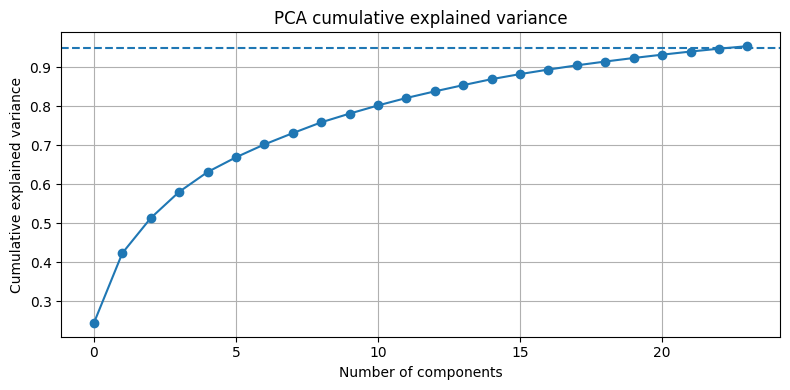

In [22]:
# ============================================================
# 10. PCA 95% explained variance
# ============================================================

pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_pca_array = pca.fit_transform(X_corr)

pca_cols = [f"PC{i+1}" for i in range(X_pca_array.shape[1])]

X_pca = pd.DataFrame(
    X_pca_array,
    columns=pca_cols,
    index=X_corr.index
)

print("Input features after correlation filter:", X_corr.shape[1])
print("PCA components retained:", X_pca.shape[1])
print("Total explained variance:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.axhline(0.95, linestyle="--")
plt.title("PCA cumulative explained variance")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.grid(True)
plt.tight_layout()
plt.show()


## 10. Dataset para CNN

Para CNN se recomienda conservar las matrices multibanda. Esta sección opcional crea tensores con forma:

`samples × channels × height × width`

Se redimensionan los patches a `64 × 64` para que todos tengan el mismo tamaño.


In [23]:
# ============================================================
# 11. Optional: Create CNN-ready tensors
# ============================================================

def read_patch_as_tensor(patch_path, size=64):
    patch_path = Path(patch_path)
    with rasterio.open(patch_path) as src:
        arr = src.read(
            out_shape=(src.count, size, size),
            resampling=Resampling.bilinear
        ).astype("float32")

    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return arr

available = fe_encoded.loc[fe_encoded["patch_exists"], "patch_path"].head(5).tolist()
test_tensors = np.stack([read_patch_as_tensor(p, size=64) for p in available])

print("Test tensor shape:", test_tensors.shape)
print("Expected: samples x channels x height x width")


Test tensor shape: (5, 7, 64, 64)
Expected: samples x channels x height x width


In [ ]:
# ============================================================
# 11.1 Save full CNN tensor dataset
# ============================================================

cnn_df = fe_encoded[fe_encoded["patch_exists"] & fe_encoded["stress_class"].notna()].copy()
X_img = np.stack([read_patch_as_tensor(p, size=64) for p in cnn_df["patch_path"]])
y_img = cnn_df["stress_class"].values

np.savez_compressed(
    OUTPUT_DIR / "avocado_cnn_tensors_64x64.npz",
    X=X_img,
    y=y_img,
    patch_path=cnn_df["patch_path"].values,
    name=cnn_df["name"].values,
    year=cnn_df["year_x"].values,
    month=cnn_df["month_x"].values
 )

print("Saved CNN tensor dataset:", X_img.shape)


Saved CNN tensor dataset: (4000, 7, 64, 64)


## 11. Guardar datasets finales

Se generan:

- dataset completo con features generadas,
- dataset con top features por ANOVA,
- dataset con top features por Mutual Information,
- dataset compacto con PCA,
- tablas de puntuación de selección de características.


In [28]:
# ============================================================
# 12. Save outputs
# ============================================================

meta_cols = [c for c in ["name", "year", "month", "year_month", "patch_path", "stress_class"] if c in fe_encoded.columns]
metadata_valid = fe_encoded.loc[X_corr.index, meta_cols].reset_index(drop=True)

full_engineered = pd.concat(
    [fe_encoded[meta_cols].reset_index(drop=True), X_clipped.reset_index(drop=True)],
    axis=1
)
full_engineered.to_csv(OUTPUT_DIR / "avocado_level2_full_engineered_features.csv", index=False)

anova_dataset = pd.concat(
    [metadata_valid, X_corr[top_anova_features].reset_index(drop=True)],
    axis=1
)
anova_dataset.to_csv(OUTPUT_DIR / "avocado_level2_top_anova_features.csv", index=False)

mi_dataset = pd.concat(
    [metadata_valid, X_corr[top_mi_features].reset_index(drop=True)],
    axis=1
)
mi_dataset.to_csv(OUTPUT_DIR / "avocado_level2_top_mutual_info_features.csv", index=False)

pca_dataset = pd.concat(
    [metadata_valid, X_pca.reset_index(drop=True)],
    axis=1
)
pca_dataset.to_csv(OUTPUT_DIR / "avocado_level2_pca_95_variance.csv", index=False)

anova_scores.to_csv(OUTPUT_DIR / "feature_selection_anova_scores.csv", index=False)
mi_scores.to_csv(OUTPUT_DIR / "feature_selection_mutual_info_scores.csv", index=False)

print("Saved outputs to:", OUTPUT_DIR)
print("Full engineered:", full_engineered.shape)
print("ANOVA dataset:", anova_dataset.shape)
print("MI dataset:", mi_dataset.shape)
print("PCA dataset:", pca_dataset.shape)


Saved outputs to: C:\Users\omarh\Desktop\Maestria\avocado_project\data\processed\feature_engineering
Full engineered: (4100, 102)
ANOVA dataset: (4000, 34)
MI dataset: (4000, 34)
PCA dataset: (4000, 28)


## 12. Conclusiones — Data Preparation en CRISP‑ML

En esta fase de **Data Preparation / Feature Engineering** se transformaron datos crudos de Sentinel‑2 y GeoTIFFs en variables útiles para machine learning.

### Decisiones y justificación

1. **Generación de nuevas características:** se crearon variables temporales, cíclicas, espectrales, de interacción, rezagos, deltas, rolling windows, anomalías por parcela y estadísticas raster por banda.
2. **Discretización:** NDVI y NDMI se dividieron en cuantiles para crear rangos interpretables.
3. **Codificación:** se aplicó one-hot a categorías de baja cardinalidad. Se evitó one-hot de `name` para reducir riesgo de sobreajuste.
4. **Escalamiento:** se generaron versiones con StandardScaler y MinMaxScaler para acelerar convergencia de algoritmos sensibles a escala.
5. **Transformación:** Yeo-Johnson se aplicó para mitigar sesgo y mejorar la distribución de variables.
6. **Selección de características:** se aplicó umbral de varianza, filtro por correlación, ANOVA y Mutual Information.
7. **Extracción de características:** PCA redujo dimensionalidad conservando 95% de varianza; además se preservan tensores multibanda para futuros modelos CNN.

### Dataset recomendado

Para un primer modelo clásico:

```text
avocado_level2_top_anova_features.csv
```

Para una versión compacta:

```text
avocado_level2_pca_95_variance.csv
```

Para CNN:

```text
avocado_cnn_tensors_64x64.npz
```

### Riesgos mitigados

- Sobredimensionalidad al evitar aplanar píxeles como columnas tabulares.
- Sobreajuste por alta cardinalidad al no usar `name` como one-hot.
- Redundancia por correlación mediante filtro de correlación.
- Diferencias de escala mediante escalamiento.
- Complejidad y almacenamiento mediante PCA y selección de características.

### Limitación

La clase `stress_class` sigue siendo preliminar, ya que se deriva de NDMI. La validación final requiere datos de campo, asesoría agronómica o etiquetas confirmadas.
